# Turkish News & Tweet Classification with E5 and Jina Embeddings

Compares two embedding models as feature extractors for classic classifiers on two very different Turkish text types:

| Dataset | Task | Samples used |
|---|---|---|
| [`yankihue/turkish-news-categories`](https://huggingface.co/datasets/yankihue/turkish-news-categories) | 7-class news headline topic | 5,397 (771 per class) |
| [`yankihue/tweets-turkish`](https://huggingface.co/datasets/yankihue/tweets-turkish) | binary tweet sentiment | 6,000 (3,000 per class) |

**Representations:** `intfloat/e5-small` (384-d), Jina embeddings via API (1024-d), and their concatenation (1408-d).
**Classifiers:** Logistic Regression, SVM, Random Forest, KNN.
Finally, an **"improved space"** expands the embeddings with new features built from random feature subsets (1.5×–5×).

#### News headlines are formal and clean.
#### Tweets are short, informal and noisy.
#### Combining the two shows how embedding methods perform across a wide range of text styles.

In [7]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np

### 1. Downloading and Preparing the Datasets

In [3]:
#news_dataset = load_dataset("turkish_news_category")
from datasets import load_dataset

# Load the news headline dataset
news_dataset = load_dataset("yankihue/turkish-news-categories")

In [4]:
import pandas as pd

# Get the training set as a DataFrame
news_df = pd.DataFrame(news_dataset['train'])
print(news_df.head())

                                            headline category
0                             'Ortak vizyonumuz var'    dunya
1          İsrail'den Gazze Şeridi'ne hava saldırısı    dunya
2        Cenaze için geniş güvenlik önlemleri alındı    dunya
3                  Gözaltındaki sendikacılar serbest    dunya
4  Bisikletle Asya'da 3 bin kilometre yol katettiler    dunya


In [7]:
# Number of samples and label distribution (news headlines)
print(f"Total samples (news): {news_df.shape[0]}")
print("Label distribution (news categories):")
print(news_df["category"].value_counts())

Total samples (news): 24097
Label distribution (news categories):
category
spor         9997
dunya        5677
ekonomi      3265
siyaset      1849
saglik       1383
kultur       1155
teknoloji     771
Name: count, dtype: int64


In [9]:
# Load the tweet dataset
tweets_dataset = load_dataset("yankihue/tweets-turkish")

In [10]:
# Get the training set as a DataFrame
tweets_df = pd.DataFrame(tweets_dataset['train'])
print(tweets_df.head())

                                            Paylaşım      Tip
0                      Doğa ağzımıza sıçsa hakkı var  Negatif
1  Anne bir sanatçıdır, en güzel eseri de yavrusu...  Pozitif
2   ibrahimin oğlunu koruyan Tanrıya da ben sokayım  Negatif
3        Köpeğim suratına sıçsın senin namussuz karı  Negatif
4                Ben söğüşledim, birazda sen söğüşle  Negatif


In [13]:
# Number of samples and label distribution (tweets)
print(f"Total samples (tweets): {tweets_df.shape[0]}")
print("Label distribution (tweet sentiment):")
print(tweets_df["Tip"].value_counts())

Total samples (tweets): 11108
Label distribution (tweet sentiment):
Tip
Pozitif     6109
Negatif     4998
 Negatif       1
Name: count, dtype: int64


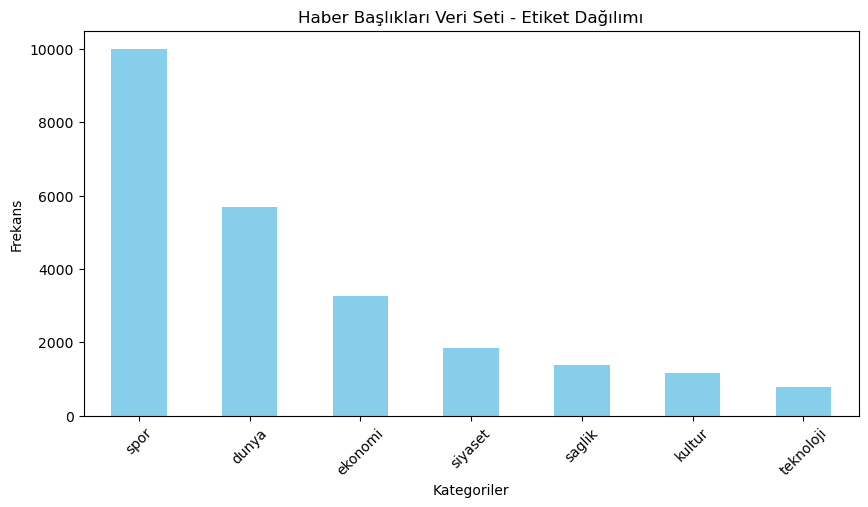

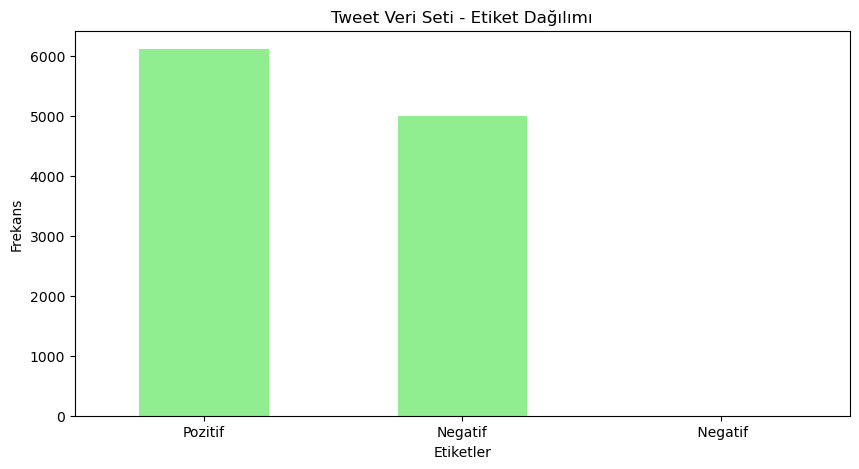

In [15]:
import matplotlib.pyplot as plt

# News headline distribution
news_distribution = news_df["category"].value_counts()
plt.figure(figsize=(10, 5))
news_distribution.plot(kind="bar", color="skyblue")
plt.title("Haber Başlıkları Veri Seti - Etiket Dağılımı")
plt.xlabel("Kategoriler")
plt.ylabel("Frekans")
plt.xticks(rotation=45)
plt.show()

# Tweet distribution
tweets_distribution = tweets_df["Tip"].value_counts()
plt.figure(figsize=(10, 5))
tweets_distribution.plot(kind="bar", color="lightgreen")
plt.title("Tweet Veri Seti - Etiket Dağılımı")
plt.xlabel("Etiketler")
plt.ylabel("Frekans")
plt.xticks(rotation=0)
plt.show()

In [27]:
import pandas as pd

# Take an equal number of samples per category (news headlines)
def balance_and_save_news_dataset(news_df, n_per_category, output_file):
    balanced_news_df = news_df.groupby("category", group_keys=False).apply(
        lambda x: x.sample(n=n_per_category, random_state=42) if len(x) >= n_per_category else x
    )
    balanced_news_df.to_csv(output_file, index=False)
    print(f"Balanced news headline dataset '{output_file}' saved.")

# Take an equal number of positive and negative tweets
def balance_and_save_tweets_dataset(tweets_df, n_per_label, output_file):
    balanced_tweets_df = tweets_df[tweets_df["Tip"].isin(["Pozitif", "Negatif"])]
    balanced_tweets_df = balanced_tweets_df.groupby("Tip", group_keys=False).apply(
        lambda x: x.sample(n=n_per_label, random_state=42) if len(x) >= n_per_label else x
    )
    balanced_tweets_df.to_csv(output_file, index=False)
    print(f"Balanced tweet dataset '{output_file}' saved.")

# Example usage
# Take 771 samples per category for news headlines and save
balance_and_save_news_dataset(news_df, n_per_category=771, output_file="balanced_news_dataset.csv")

# Take 3000 positive and negative tweets and save
balance_and_save_tweets_dataset(tweets_df, n_per_label=3000, output_file="balanced_tweets_dataset.csv")

Balanced news headline dataset 'balanced_news_dataset.csv' saved.
Balanced tweet dataset 'balanced_tweets_dataset.csv' saved.


In [7]:
news = pd.read_csv("balanced_news_dataset.csv")
tweets= pd.read_csv("balanced_tweets_dataset.csv")

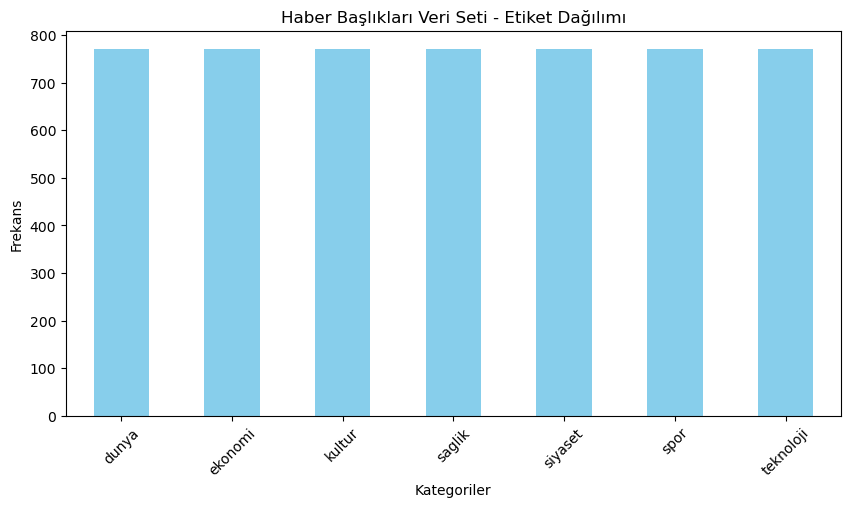

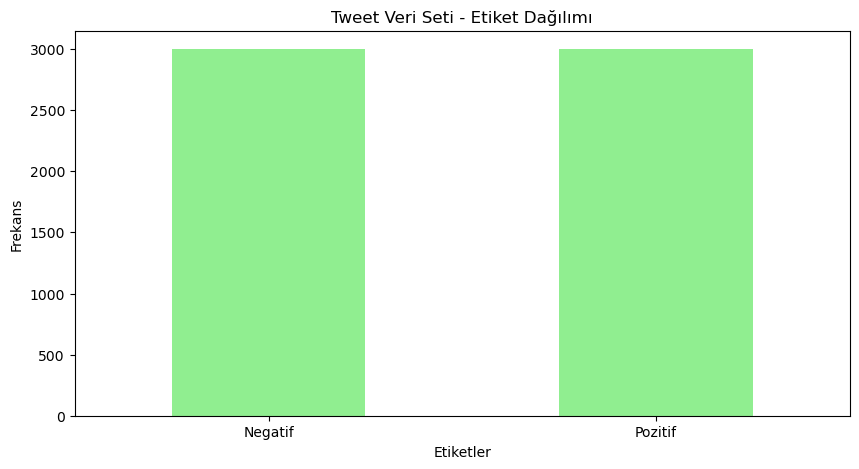

In [11]:
import matplotlib.pyplot as plt

# News headline distribution
news_distribution_2 = news["category"].value_counts()
plt.figure(figsize=(10, 5))
news_distribution_2.plot(kind="bar", color="skyblue")
plt.title("Haber Başlıkları Veri Seti - Etiket Dağılımı")
plt.xlabel("Kategoriler")
plt.ylabel("Frekans")
plt.xticks(rotation=45)
plt.show()

# Tweet distribution
tweets_distribution_2 = tweets["Tip"].value_counts()
plt.figure(figsize=(10, 5))
tweets_distribution_2.plot(kind="bar", color="lightgreen")
plt.title("Tweet Veri Seti - Etiket Dağılımı")
plt.xlabel("Etiketler")
plt.ylabel("Frekans")
plt.xticks(rotation=0)
plt.show()

#### Text Length Analysis
Compute and analyze the average length of news headlines and tweets.

In [21]:
news_df['headline_length'] = news_df['headline'].apply(len)
print(news_df['headline_length'].describe())

count    24097.000000
mean        33.243806
std          9.660399
min          3.000000
25%         26.000000
50%         33.000000
75%         39.000000
max         91.000000
Name: headline_length, dtype: float64


In [24]:
tweets_df['Paylaşım_length'] = tweets_df['Paylaşım'].apply(len)
print(tweets_df['Paylaşım_length'].describe())

count    11108.000000
mean        79.330302
std         59.035705
min          3.000000
25%         36.000000
50%         64.000000
75%        106.000000
max        508.000000
Name: Paylaşım_length, dtype: float64


### 2. Applying the Representation Methods

#### E5

In [24]:
import time
import numpy as np
from transformers import AutoTokenizer, AutoModel
import torch

# Load the E5 embedding model
tokenizer = AutoTokenizer.from_pretrained("intfloat/e5-small")
model = AutoModel.from_pretrained("intfloat/e5-small")

from tqdm import tqdm  # For the progress bar

# Extract E5 embeddings from texts (with tqdm)
def get_e5_embeddings_with_progress(texts):
    embeddings_list = []
    start_time = time.time()  # Start timer
    
    for text in tqdm(texts, desc="E5 embedding", unit="metin"):
        inputs = tokenizer(text, padding=True, truncation=True, max_length=512, return_tensors="pt")
        outputs = model(**inputs)
        embedding = outputs.last_hidden_state.mean(dim=1)
        embeddings_list.append(embedding.detach().numpy())
    
    elapsed_time = time.time() - start_time  
    print(f"E5 embedding done. Time: {elapsed_time:.2f} seconds.")
    return np.vstack(embeddings_list)  

# Save embeddings
def save_embeddings(embeddings, file_name):
    np.save(file_name, embeddings)
    print(f"Embeddings '{file_name}' saved.")
    
# E5 embeddings for news headlines
news_texts = news['headline'].tolist()
print("Starting E5 embedding for news headlines...")
news_e5_embeddings = get_e5_embeddings_with_progress(news_texts)

# Save E5 embeddings for news headlines
save_embeddings(news_e5_embeddings, "news_e5_embeddings.npy")


Starting E5 embedding for news headlines...


E5 embedding done. Time: 114.06 seconds.
Embeddings 'news_e5_embeddings.npy' saved.


In [29]:
# E5 embeddings for tweets
tweets_texts = tweets['Paylaşım'].tolist()  
print("Starting E5 embedding for tweets...")
tweets_e5_embeddings = get_e5_embeddings_with_progress(tweets_texts)

# Save E5 embeddings for tweets
save_embeddings(tweets_e5_embeddings, "tweets_e5_embeddings.npy")

Starting E5 embedding for tweets...


E5 embedding done. Time: 143.25 seconds.
Embeddings 'tweets_e5_embeddings.npy' saved.


In [13]:
import numpy as np
# Load embeddings
def load_embeddings(file_name):
    embeddings = np.load(file_name)
    print(f"Embeddings '{file_name}' loaded from file.")
    return embeddings

# Load news headline embeddings
news_e5_embeddings_loaded = load_embeddings("news_e5_embeddings.npy")

# Load tweet embeddings
tweets_e5_embeddings_loaded = load_embeddings("tweets_e5_embeddings.npy")

Embeddings 'news_e5_embeddings.npy' loaded from file.
Embeddings 'tweets_e5_embeddings.npy' loaded from file.


#### Jina

In [48]:
import os
import pandas as pd
import requests
import json
import numpy as np
import time

# API URL and headers
url = 'https://api.jina.ai/v1/embeddings'
headers = {
    'Content-Type': 'application/json',
    'Authorization': f"Bearer {os.environ['JINA_API_KEY']}"  # set JINA_API_KEY in your environment
}

# Load news headlines
news_df = pd.read_csv("balanced_news_dataset.csv")

# Convert news headlines to JSON
news_texts = news_df['headline'].tolist()

# Set batch size
batch_size = 50

# Create a list to collect all embeddings
news_embeddings = []

# Start time for total processing time
total_start_time = time.time()

# Batch processing
for i in range(0, len(news_texts), batch_size):
    batch = news_texts[i:i + batch_size]  # Create batch
    input_data = [{"text": text} for text in batch]
    
    data = {
        "model": "jina-clip-v2",  # model name
        "dimensions": 1024,
        "normalized": True,
        "embedding_type": "float",
        "input": input_data
    }
    
    # Measure time per batch
    batch_start_time = time.time()
    response = requests.post(url, headers=headers, data=json.dumps(data))
    batch_end_time = time.time()
    
    # Check the response
    if response.status_code == 200:
        # Get embeddings from the response
        response_data = response.json()
        batch_embeddings = [item['embedding'] for item in response_data.get('data', [])]
        
        # If the batch returned embeddings, append them
        if batch_embeddings:
            news_embeddings.extend(batch_embeddings)
            print(f"Batch {i // batch_size + 1} done. Time: {batch_end_time - batch_start_time:.2f} seconds.")
        else:
            print(f"Batch {i // batch_size + 1} returned empty embeddings. Time: {batch_end_time - batch_start_time:.2f} seconds.")
    else:
        print(f"Hata: Batch {i // batch_size + 1} - {response.status_code} - {response.text}")
        break  # Stop the loop on error

# Measure total processing time
total_end_time = time.time()

# Save all embeddings
if news_embeddings:
    np.save("news_jina_embeddings.npy", np.array(news_embeddings))
    print("Tüm embedding'ler başarıyla kaydedildi.")
else:
    print("Embedding extraction failed.")

# Print total time
print(f"Total processing time: {total_end_time - total_start_time:.2f} seconds.")

Batch 1 done. Time: 1.59 seconds.
Batch 2 done. Time: 1.58 seconds.
Batch 3 done. Time: 1.52 seconds.
Batch 4 done. Time: 1.94 seconds.
Batch 5 done. Time: 1.26 seconds.
Batch 6 done. Time: 1.51 seconds.
Batch 7 done. Time: 1.55 seconds.
Batch 8 done. Time: 1.65 seconds.
Batch 9 done. Time: 1.81 seconds.
Batch 10 done. Time: 1.54 seconds.
Batch 11 done. Time: 1.29 seconds.
Batch 12 done. Time: 1.57 seconds.
Batch 13 done. Time: 1.55 seconds.
Batch 14 done. Time: 1.48 seconds.
Batch 15 done. Time: 1.62 seconds.
Batch 16 done. Time: 1.93 seconds.
Batch 17 done. Time: 1.73 seconds.
Batch 18 done. Time: 1.66 seconds.
Batch 19 done. Time: 2.00 seconds.
Batch 20 done. Time: 1.45 seconds.
Batch 21 done. Time: 1.39 seconds.
Batch 22 done. Time: 1.57 seconds.
Batch 23 done. Time: 1.62 seconds.
Batch 24 done. Time: 1.51 seconds.
Batch 25 done. Time: 1.50 seconds.
Batch 26 done. Time: 1.52 seconds.
Batch 27 done. Time: 1.54 seconds.
Batch 28 done. Time: 1.47 seconds.
Batch 29 done. Time: 1.50 sec

In [50]:
import os
import pandas as pd
import requests
import json
import numpy as np
import time

# API URL and headers
url = 'https://api.jina.ai/v1/embeddings'
headers = {
    'Content-Type': 'application/json',
    'Authorization': f"Bearer {os.environ['JINA_API_KEY']}"  # set JINA_API_KEY in your environment
}

# Load the tweet dataset
tweets_df = pd.read_csv("balanced_tweets_dataset.csv")

# Convert tweet texts to JSON
tweets_texts = tweets_df['Paylaşım'].tolist()

# Filter out empty or very short tweets
tweets_texts = [text for text in tweets_texts if isinstance(text, str) and text.strip()]

# Set batch size
batch_size = 50

# Create a list to collect all embeddings
tweets_embeddings = []

# Start time for total processing time
total_start_time = time.time()

# Batch processing
for i in range(0, len(tweets_texts), batch_size):
    batch = tweets_texts[i:i + batch_size]  # Create batch
    input_data = [{"text": text} for text in batch]
    
    data = {
        "model": "jina-clip-v2",  # model name
        "dimensions": 1024,
        "normalized": True,
        "embedding_type": "float",
        "input": input_data
    }
    
    # Measure time per batch
    batch_start_time = time.time()
    response = requests.post(url, headers=headers, data=json.dumps(data))
    batch_end_time = time.time()
    
    # Check the response
    if response.status_code == 200:
        # Get embeddings from the response
        response_data = response.json()
        batch_embeddings = [item['embedding'] for item in response_data.get('data', [])]
        
        # If the batch returned embeddings, append them
        if batch_embeddings:
            tweets_embeddings.extend(batch_embeddings)
            print(f"Batch {i // batch_size + 1} done. Time: {batch_end_time - batch_start_time:.2f} seconds.")
        else:
            print(f"Batch {i // batch_size + 1} returned empty embeddings. Time: {batch_end_time - batch_start_time:.2f} seconds.")
    else:
        print(f"Hata: Batch {i // batch_size + 1} - {response.status_code} - {response.text}")
        break  # Stop the loop on error

# Measure total processing time
total_end_time = time.time()

# Save all embeddings
if tweets_embeddings:
    np.save("tweets_jina_embeddings.npy", np.array(tweets_embeddings))
    print("Tüm embedding'ler başarıyla kaydedildi.")
else:
    print("Embedding extraction failed.")

# Print total time
print(f"Total processing time: {total_end_time - total_start_time:.2f} seconds.")

Batch 1 done. Time: 1.58 seconds.
Batch 2 done. Time: 1.61 seconds.
Batch 3 done. Time: 1.59 seconds.
Batch 4 done. Time: 1.46 seconds.
Batch 5 done. Time: 1.61 seconds.
Batch 6 done. Time: 1.51 seconds.
Batch 7 done. Time: 1.50 seconds.
Batch 8 done. Time: 1.63 seconds.
Batch 9 done. Time: 1.42 seconds.
Batch 10 done. Time: 1.64 seconds.
Batch 11 done. Time: 1.55 seconds.
Batch 12 done. Time: 1.55 seconds.
Batch 13 done. Time: 1.57 seconds.
Batch 14 done. Time: 1.57 seconds.
Batch 15 done. Time: 1.31 seconds.
Batch 16 done. Time: 1.55 seconds.
Batch 17 done. Time: 1.61 seconds.
Batch 18 done. Time: 1.55 seconds.
Batch 19 done. Time: 1.49 seconds.
Batch 20 done. Time: 1.46 seconds.
Batch 21 done. Time: 1.57 seconds.
Batch 22 done. Time: 2.38 seconds.
Batch 23 done. Time: 2.75 seconds.
Batch 24 done. Time: 1.57 seconds.
Batch 25 done. Time: 1.52 seconds.
Batch 26 done. Time: 1.54 seconds.
Batch 27 done. Time: 1.42 seconds.
Batch 28 done. Time: 1.75 seconds.
Batch 29 done. Time: 1.59 sec

In [58]:
# Load embedding files
news_jina_embeddings = np.load("news_jina_embeddings.npy")
news_e5_embeddings = np.load("news_e5_embeddings.npy")

# Check shapes
print("Jina embedding shape:", news_jina_embeddings.shape)  # e.g. (5000, 1024)
print("E5 Embedding Boyutu:", news_e5_embeddings.shape)      # e.g. (5000, 768)

Jina embedding shape: (5397, 1024)
E5 Embedding Boyutu: (5397, 384)


In [56]:
# Load embedding files
tweets_jina_embeddings = np.load("tweets_jina_embeddings.npy")
tweets_e5_embeddings = np.load("tweets_e5_embeddings.npy")

# Check shapes
print("Jina embedding shape:", tweets_jina_embeddings.shape)  # e.g. (5000, 1024)
print("E5 Embedding Boyutu:", tweets_e5_embeddings.shape)      # e.g. (5000, 768)

Jina embedding shape: (6000, 1024)
E5 Embedding Boyutu: (6000, 384)


#### 3. Concatenating Representations

In [80]:
import numpy as np

# Concatenate representations for news headlines

# Check that shapes match
assert news_jina_embeddings.shape[0] == news_e5_embeddings.shape[0], "Embedding'lerin satır sayıları eşleşmiyor!"

# Concatenate embeddings
news_combined_embeddings = np.concatenate((news_jina_embeddings, news_e5_embeddings), axis=1)

# New dimension
print("Concatenated embedding shape:", news_combined_embeddings.shape)  # (5397, 1408)

# Save concatenated embeddings
np.save("news_combined_embeddings.npy", news_combined_embeddings)
print("Birleştirilmiş embedding'ler başarıyla kaydedildi.")

Concatenated embedding shape: (5397, 1408)
Birleştirilmiş embedding'ler başarıyla kaydedildi.


In [88]:
import numpy as np

# Concatenate representations for news headlines

# Check that shapes match
assert tweets_jina_embeddings.shape[0] == tweets_e5_embeddings.shape[0], "Embedding'lerin satır sayıları eşleşmiyor!"

# Concatenate embeddings
tweets_combined_embeddings = np.concatenate((tweets_jina_embeddings, tweets_e5_embeddings), axis=1)

# New dimension
print("Concatenated embedding shape:", tweets_combined_embeddings.shape)  # (5397, 1408)

# Save concatenated embeddings
np.save("tweets_combined_embeddings.npy", tweets_combined_embeddings)
print("Birleştirilmiş embedding'ler başarıyla kaydedildi.")

Concatenated embedding shape: (6000, 1408)
Birleştirilmiş embedding'ler başarıyla kaydedildi.


#### 4. Testing Individual Representations with Classifiers

#### Logistic Regression - News Dataset

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Load embeddings
jina_embeddings = np.load("news_jina_embeddings.npy")
e5_embeddings = np.load("news_e5_embeddings.npy")

# Load labels
import pandas as pd
news_df = pd.read_csv("balanced_news_dataset.csv")
labels = news_df['category'].values  # Kategori etiketleri

# Split into train and test sets
X_train_jina, X_test_jina, y_train, y_test = train_test_split(jina_embeddings, labels, test_size=0.2, random_state=42)
X_train_e5, X_test_e5, _, _ = train_test_split(e5_embeddings, labels, test_size=0.2, random_state=42)

# Logistic Regression test with Jina
model_jina = LogisticRegression(max_iter=1000, random_state=42)
model_jina.fit(X_train_jina, y_train)
y_pred_jina = model_jina.predict(X_test_jina)
print("Jina Embedding - Accuracy:", accuracy_score(y_test, y_pred_jina))
print("Jina Embedding - Classification Report:\n", classification_report(y_test, y_pred_jina))

# Logistic Regression test with E5
model_e5 = LogisticRegression(max_iter=1000, random_state=42)
model_e5.fit(X_train_e5, y_train)
y_pred_e5 = model_e5.predict(X_test_e5)
print("E5 Embedding - Accuracy:", accuracy_score(y_test, y_pred_e5))
print("E5 Embedding - Classification Report:\n", classification_report(y_test, y_pred_e5))

Jina Embedding - Accuracy: 0.8083333333333333
Jina Embedding - Classification Report:
               precision    recall  f1-score   support

       dunya       0.74      0.71      0.73       171
     ekonomi       0.79      0.76      0.77       164
      kultur       0.78      0.83      0.80       147
      saglik       0.88      0.91      0.89       156
     siyaset       0.77      0.76      0.76       148
        spor       0.84      0.88      0.86       147
   teknoloji       0.87      0.82      0.84       147

    accuracy                           0.81      1080
   macro avg       0.81      0.81      0.81      1080
weighted avg       0.81      0.81      0.81      1080

E5 Embedding - Accuracy: 0.5194444444444445
E5 Embedding - Classification Report:
               precision    recall  f1-score   support

       dunya       0.45      0.37      0.41       171
     ekonomi       0.54      0.45      0.49       164
      kultur       0.41      0.50      0.45       147
      saglik    

#### Logistic Regression - Tweets Dataset

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Load embeddings
tweets_jina_embeddings = np.load("tweets_jina_embeddings.npy")
tweets_e5_embeddings = np.load("tweets_e5_embeddings.npy")

# Load labels
import pandas as pd
tweets_df = pd.read_csv("balanced_tweets_dataset.csv")
labels = tweets_df['Tip'].values  # Kategori etiketleri

# Split into train and test sets
X_train_jina, X_test_jina, y_train, y_test = train_test_split(tweets_jina_embeddings, labels, test_size=0.2, random_state=42)
X_train_e5, X_test_e5, _, _ = train_test_split(tweets_e5_embeddings, labels, test_size=0.2, random_state=42)

# Logistic Regression test with Jina
model_jina = LogisticRegression(max_iter=1000, random_state=42)
model_jina.fit(X_train_jina, y_train)
y_pred_jina = model_jina.predict(X_test_jina)
print("Jina Embedding - Accuracy:", accuracy_score(y_test, y_pred_jina))
print("Jina Embedding - Classification Report:\n", classification_report(y_test, y_pred_jina))

# Logistic Regression test with E5
model_e5 = LogisticRegression(max_iter=1000, random_state=42)
model_e5.fit(X_train_e5, y_train)
y_pred_e5 = model_e5.predict(X_test_e5)
print("E5 Embedding - Accuracy:", accuracy_score(y_test, y_pred_e5))
print("E5 Embedding - Classification Report:\n", classification_report(y_test, y_pred_e5))

Jina Embedding - Accuracy: 0.8425
Jina Embedding - Classification Report:
               precision    recall  f1-score   support

     Negatif       0.85      0.84      0.85       613
     Pozitif       0.84      0.84      0.84       587

    accuracy                           0.84      1200
   macro avg       0.84      0.84      0.84      1200
weighted avg       0.84      0.84      0.84      1200

E5 Embedding - Accuracy: 0.74
E5 Embedding - Classification Report:
               precision    recall  f1-score   support

     Negatif       0.76      0.72      0.74       613
     Pozitif       0.72      0.76      0.74       587

    accuracy                           0.74      1200
   macro avg       0.74      0.74      0.74      1200
weighted avg       0.74      0.74      0.74      1200



#### SVM - News Dataset

In [97]:
from sklearn.svm import SVC  # SVM classifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Load embeddings
news_jina_embeddings = np.load("news_jina_embeddings.npy")
news_e5_embeddings = np.load("news_e5_embeddings.npy")

# Load labels
news_df = pd.read_csv("balanced_news_dataset.csv")
labels = news_df['category'].values  # Kategori etiketleri

# Split into train and test sets (stratified split recommended)
X_train_jina, X_test_jina, y_train, y_test = train_test_split(
    news_jina_embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

X_train_e5, X_test_e5, _, _ = train_test_split(
    news_e5_embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

# SVM with Jina embeddings
print("\n--- Jina Embedding + SVM ---")
svm_jina = SVC(kernel='linear', random_state=42)  # Lineer kernel SVM
svm_jina.fit(X_train_jina, y_train)
y_pred_jina = svm_jina.predict(X_test_jina)

print("Accuracy:", accuracy_score(y_test, y_pred_jina))
print("Classification Report:\n", classification_report(y_test, y_pred_jina))

# SVM with E5 embeddings
print("\n--- E5 Embedding + SVM ---")
svm_e5 = SVC(kernel='linear', random_state=42)  # Lineer kernel SVM
svm_e5.fit(X_train_e5, y_train)
y_pred_e5 = svm_e5.predict(X_test_e5)

print("Accuracy:", accuracy_score(y_test, y_pred_e5))
print("Classification Report:\n", classification_report(y_test, y_pred_e5))


--- Jina Embedding + SVM ---
Accuracy: 0.7953703703703704
Classification Report:
               precision    recall  f1-score   support

       dunya       0.69      0.72      0.70       154
     ekonomi       0.75      0.74      0.75       154
      kultur       0.77      0.81      0.79       154
      saglik       0.88      0.89      0.89       155
     siyaset       0.76      0.81      0.78       154
        spor       0.90      0.84      0.87       154
   teknoloji       0.83      0.77      0.80       155

    accuracy                           0.80      1080
   macro avg       0.80      0.80      0.80      1080
weighted avg       0.80      0.80      0.80      1080


--- E5 Embedding + SVM ---
Accuracy: 0.5166666666666667
Classification Report:
               precision    recall  f1-score   support

       dunya       0.41      0.45      0.43       154
     ekonomi       0.41      0.44      0.42       154
      kultur       0.49      0.51      0.50       154
      saglik       0.5

#### SVM - Tweets Dataset

In [91]:
from sklearn.svm import SVC  # SVM classifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Load embeddings
tweets_jina_embeddings = np.load("tweets_jina_embeddings.npy")
tweets_e5_embeddings = np.load("tweets_e5_embeddings.npy")

# Load labels
tweets_df = pd.read_csv("balanced_tweets_dataset.csv")
labels = tweets_df['Tip'].values  # Kategori etiketleri

# Split into train and test sets (stratified split recommended)
X_train_jina, X_test_jina, y_train, y_test = train_test_split(
    tweets_jina_embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

X_train_e5, X_test_e5, _, _ = train_test_split(
    tweets_e5_embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

# SVM with Jina embeddings
print("\n--- Jina Embedding + SVM ---")
svm_jina = SVC(kernel='linear', random_state=42)  # Lineer kernel SVM
svm_jina.fit(X_train_jina, y_train)
y_pred_jina = svm_jina.predict(X_test_jina)

print("Accuracy:", accuracy_score(y_test, y_pred_jina))
print("Classification Report:\n", classification_report(y_test, y_pred_jina))

# SVM with E5 embeddings
print("\n--- E5 Embedding + SVM ---")
svm_e5 = SVC(kernel='linear', random_state=42)  # Lineer kernel SVM
svm_e5.fit(X_train_e5, y_train)
y_pred_e5 = svm_e5.predict(X_test_e5)

print("Accuracy:", accuracy_score(y_test, y_pred_e5))
print("Classification Report:\n", classification_report(y_test, y_pred_e5))


--- Jina Embedding + SVM ---
Accuracy: 0.8433333333333334
Classification Report:
               precision    recall  f1-score   support

     Negatif       0.84      0.85      0.84       600
     Pozitif       0.85      0.84      0.84       600

    accuracy                           0.84      1200
   macro avg       0.84      0.84      0.84      1200
weighted avg       0.84      0.84      0.84      1200


--- E5 Embedding + SVM ---
Accuracy: 0.7225
Classification Report:
               precision    recall  f1-score   support

     Negatif       0.72      0.73      0.72       600
     Pozitif       0.72      0.72      0.72       600

    accuracy                           0.72      1200
   macro avg       0.72      0.72      0.72      1200
weighted avg       0.72      0.72      0.72      1200



#### Random Forest - News Dataset

In [104]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Load embeddings
news_jina_embeddings = np.load("news_jina_embeddings.npy")
news_e5_embeddings = np.load("news_e5_embeddings.npy")

# Load labels
news_df = pd.read_csv("balanced_news_dataset.csv")
labels = news_df['category'].values  # Kategori etiketleri

# Split into train and test sets (stratified split recommended)
X_train_jina, X_test_jina, y_train, y_test = train_test_split(
    news_jina_embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

X_train_e5, X_test_e5, _, _ = train_test_split(
    news_e5_embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

# Random Forest with Jina embeddings
print("\n--- Jina Embedding + Random Forest ---")
rf_jina = RandomForestClassifier(n_estimators=100, random_state=42)
rf_jina.fit(X_train_jina, y_train)
y_pred_jina = rf_jina.predict(X_test_jina)

print("Accuracy:", accuracy_score(y_test, y_pred_jina))
print("Classification Report:\n", classification_report(y_test, y_pred_jina))

# Random Forest with E5 embeddings
print("\n--- E5 Embedding + Random Forest ---")
rf_e5 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_e5.fit(X_train_e5, y_train)
y_pred_e5 = rf_e5.predict(X_test_e5)

print("Accuracy:", accuracy_score(y_test, y_pred_e5))
print("Classification Report:\n", classification_report(y_test, y_pred_e5))


--- Jina Embedding + Random Forest ---
Accuracy: 0.7685185185185185
Classification Report:
               precision    recall  f1-score   support

       dunya       0.69      0.62      0.65       154
     ekonomi       0.73      0.65      0.69       154
      kultur       0.76      0.86      0.80       154
      saglik       0.81      0.85      0.83       155
     siyaset       0.72      0.83      0.77       154
        spor       0.85      0.82      0.83       154
   teknoloji       0.82      0.75      0.79       155

    accuracy                           0.77      1080
   macro avg       0.77      0.77      0.77      1080
weighted avg       0.77      0.77      0.77      1080


--- E5 Embedding + Random Forest ---
Accuracy: 0.46296296296296297
Classification Report:
               precision    recall  f1-score   support

       dunya       0.27      0.34      0.30       154
     ekonomi       0.42      0.42      0.42       154
      kultur       0.45      0.38      0.41       154
 

#### Random Forest - Tweets Dataset

In [101]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Load embeddings
tweets_jina_embeddings = np.load("tweets_jina_embeddings.npy")
tweets_e5_embeddings = np.load("tweets_e5_embeddings.npy")

# Load labels
tweets_df = pd.read_csv("balanced_tweets_dataset.csv")
labels = tweets_df['Tip'].values  # Kategori etiketleri

# Split into train and test sets (stratified split recommended)
X_train_jina, X_test_jina, y_train, y_test = train_test_split(
    tweets_jina_embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

X_train_e5, X_test_e5, _, _ = train_test_split(
    tweets_e5_embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

# Random Forest with Jina embeddings
print("\n--- Jina Embedding + Random Forest ---")
rf_jina = RandomForestClassifier(n_estimators=100, random_state=42)
rf_jina.fit(X_train_jina, y_train)
y_pred_jina = rf_jina.predict(X_test_jina)

print("Accuracy:", accuracy_score(y_test, y_pred_jina))
print("Classification Report:\n", classification_report(y_test, y_pred_jina))

# Random Forest with E5 embeddings
print("\n--- E5 Embedding + Random Forest ---")
rf_e5 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_e5.fit(X_train_e5, y_train)
y_pred_e5 = rf_e5.predict(X_test_e5)

print("Accuracy:", accuracy_score(y_test, y_pred_e5))
print("Classification Report:\n", classification_report(y_test, y_pred_e5))


--- Jina Embedding + Random Forest ---
Accuracy: 0.8225
Classification Report:
               precision    recall  f1-score   support

     Negatif       0.83      0.81      0.82       600
     Pozitif       0.82      0.83      0.82       600

    accuracy                           0.82      1200
   macro avg       0.82      0.82      0.82      1200
weighted avg       0.82      0.82      0.82      1200


--- E5 Embedding + Random Forest ---
Accuracy: 0.6941666666666667
Classification Report:
               precision    recall  f1-score   support

     Negatif       0.70      0.69      0.69       600
     Pozitif       0.69      0.70      0.69       600

    accuracy                           0.69      1200
   macro avg       0.69      0.69      0.69      1200
weighted avg       0.69      0.69      0.69      1200



#### KNN - News Dataset

In [114]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Load embeddings
news_jina_embeddings = np.load("news_jina_embeddings.npy")
news_e5_embeddings = np.load("news_e5_embeddings.npy")

# Load labels
news_df = pd.read_csv("balanced_news_dataset.csv")
labels = news_df['category'].values  # Kategori etiketleri

# Split into train and test sets (stratified)
X_train_jina, X_test_jina, y_train, y_test = train_test_split(
    news_jina_embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

X_train_e5, X_test_e5, _, _ = train_test_split(
    news_e5_embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

# KNN test with Jina embeddings
print("\n--- Jina Embedding + KNN ---")
knn_jina = KNeighborsClassifier(n_neighbors=5)  # 5 neighbors
knn_jina.fit(X_train_jina, y_train)
y_pred_jina = knn_jina.predict(X_test_jina)

print("Accuracy:", accuracy_score(y_test, y_pred_jina))
print("Classification Report:\n", classification_report(y_test, y_pred_jina))

# KNN test with E5 embeddings
print("\n--- E5 Embedding + KNN ---")
knn_e5 = KNeighborsClassifier(n_neighbors=5)  # 5 neighbors
knn_e5.fit(X_train_e5, y_train)
y_pred_e5 = knn_e5.predict(X_test_e5)

print("Accuracy:", accuracy_score(y_test, y_pred_e5))
print("Classification Report:\n", classification_report(y_test, y_pred_e5))


--- Jina Embedding + KNN ---
Accuracy: 0.7657407407407407
Classification Report:
               precision    recall  f1-score   support

       dunya       0.66      0.66      0.66       154
     ekonomi       0.73      0.64      0.68       154
      kultur       0.76      0.79      0.77       154
      saglik       0.77      0.91      0.84       155
     siyaset       0.74      0.81      0.77       154
        spor       0.90      0.79      0.84       154
   teknoloji       0.80      0.77      0.79       155

    accuracy                           0.77      1080
   macro avg       0.77      0.77      0.76      1080
weighted avg       0.77      0.77      0.76      1080


--- E5 Embedding + KNN ---
Accuracy: 0.5305555555555556
Classification Report:
               precision    recall  f1-score   support

       dunya       0.37      0.49      0.42       154
     ekonomi       0.49      0.44      0.46       154
      kultur       0.47      0.47      0.47       154
      saglik       0.5

#### KNN - Tweets Dataset

In [111]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Load embeddings
tweets_jina_embeddings = np.load("tweets_jina_embeddings.npy")
tweets_e5_embeddings = np.load("tweets_e5_embeddings.npy")

# Load labels
tweets_df = pd.read_csv("balanced_tweets_dataset.csv")
labels = tweets_df['Tip'].values  # Kategori etiketleri

# Split into train and test sets (stratified)
X_train_jina, X_test_jina, y_train, y_test = train_test_split(
    tweets_jina_embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

X_train_e5, X_test_e5, _, _ = train_test_split(
    tweets_e5_embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

# KNN test with Jina embeddings
print("\n--- Jina Embedding + KNN ---")
knn_jina = KNeighborsClassifier(n_neighbors=5)  # 5 neighbors
knn_jina.fit(X_train_jina, y_train)
y_pred_jina = knn_jina.predict(X_test_jina)

print("Accuracy:", accuracy_score(y_test, y_pred_jina))
print("Classification Report:\n", classification_report(y_test, y_pred_jina))

# KNN test with E5 embeddings
print("\n--- E5 Embedding + KNN ---")
knn_e5 = KNeighborsClassifier(n_neighbors=5)  # 5 neighbors
knn_e5.fit(X_train_e5, y_train)
y_pred_e5 = knn_e5.predict(X_test_e5)

print("Accuracy:", accuracy_score(y_test, y_pred_e5))
print("Classification Report:\n", classification_report(y_test, y_pred_e5))


--- Jina Embedding + KNN ---
Accuracy: 0.7575
Classification Report:
               precision    recall  f1-score   support

     Negatif       0.70      0.90      0.79       600
     Pozitif       0.86      0.61      0.72       600

    accuracy                           0.76      1200
   macro avg       0.78      0.76      0.75      1200
weighted avg       0.78      0.76      0.75      1200


--- E5 Embedding + KNN ---
Accuracy: 0.6908333333333333
Classification Report:
               precision    recall  f1-score   support

     Negatif       0.67      0.74      0.71       600
     Pozitif       0.71      0.64      0.67       600

    accuracy                           0.69      1200
   macro avg       0.69      0.69      0.69      1200
weighted avg       0.69      0.69      0.69      1200



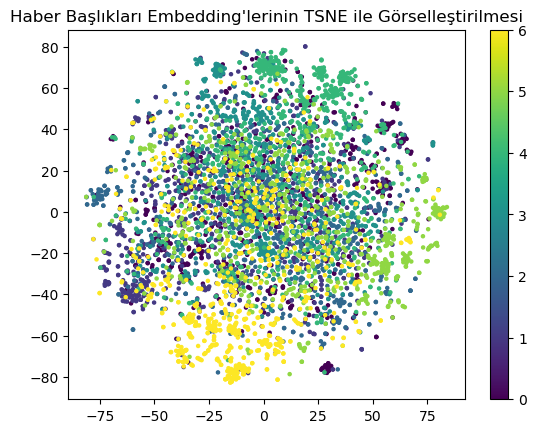

In [39]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# t-SNE for news headlines
tsne = TSNE(n_components=2, random_state=42)
news_tsne = tsne.fit_transform(news_e5_embeddings_loaded)

# Visualization
plt.scatter(news_tsne[:, 0], news_tsne[:, 1], c=news['category'].factorize()[0], cmap='viridis', s=5)
plt.colorbar()
plt.title("Haber Başlıkları Embedding'lerinin TSNE ile Görselleştirilmesi")
plt.show()

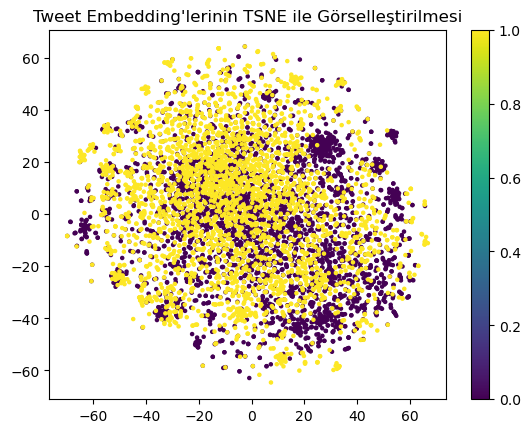

In [41]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# t-SNE for news headlines
tsne = TSNE(n_components=2, random_state=42)
tweets_tsne = tsne.fit_transform(tweets_e5_embeddings_loaded)

# Visualization
plt.scatter(tweets_tsne[:, 0], tweets_tsne[:, 1], c=tweets['Tip'].factorize()[0], cmap='viridis', s=5)
plt.colorbar()
plt.title("Tweet Embedding'lerinin TSNE ile Görselleştirilmesi")
plt.show()


#### 5. Testing Concatenated Representations with Classifiers

#### Concatenated Embedding + Logistic Regression - News Dataset

In [133]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Load embeddings
news_jina_embeddings = np.load("news_jina_embeddings.npy")
news_e5_embeddings = np.load("news_e5_embeddings.npy")

# Concatenated embedding
news_combined_embeddings = np.concatenate((news_jina_embeddings, news_e5_embeddings), axis=1)

# Load labels
news_df = pd.read_csv("balanced_news_dataset.csv")
labels = news_df['category'].values  # Kategori etiketleri

# Split into train and test sets (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    news_combined_embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

# Create and train a Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

# Test and evaluate results
y_pred = logistic_model.predict(X_test)

print("Concatenated embedding + Logistic Regression - Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Concatenated embedding + Logistic Regression - Accuracy: 0.7870370370370371
Classification Report:
               precision    recall  f1-score   support

       dunya       0.69      0.69      0.69       154
     ekonomi       0.72      0.73      0.72       154
      kultur       0.79      0.81      0.80       154
      saglik       0.87      0.87      0.87       155
     siyaset       0.76      0.82      0.79       154
        spor       0.88      0.83      0.85       154
   teknoloji       0.81      0.75      0.78       155

    accuracy                           0.79      1080
   macro avg       0.79      0.79      0.79      1080
weighted avg       0.79      0.79      0.79      1080



#### Concatenated Embedding + Logistic Regression - Tweets Dataset

In [131]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Load embeddings
tweets_jina_embeddings = np.load("tweets_jina_embeddings.npy")
tweets_e5_embeddings = np.load("tweets_e5_embeddings.npy")

# Concatenated embedding
tweets_combined_embeddings = np.concatenate((tweets_jina_embeddings, tweets_e5_embeddings), axis=1)

# Load labels
tweets_df = pd.read_csv("balanced_tweets_dataset.csv")
labels = tweets_df['Tip'].values  # Kategori etiketleri

# Split into train and test sets (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    tweets_combined_embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

# Create and train a Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

# Test and evaluate results
y_pred = logistic_model.predict(X_test)

print("Concatenated embedding + Logistic Regression - Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Concatenated embedding + Logistic Regression - Accuracy: 0.8483333333333334
Classification Report:
               precision    recall  f1-score   support

     Negatif       0.86      0.84      0.85       600
     Pozitif       0.84      0.86      0.85       600

    accuracy                           0.85      1200
   macro avg       0.85      0.85      0.85      1200
weighted avg       0.85      0.85      0.85      1200



#### Concatenated Embedding + SVM - News Dataset

In [129]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Load embeddings
news_jina_embeddings = np.load("news_jina_embeddings.npy")
news_e5_embeddings = np.load("news_e5_embeddings.npy")

# Concatenated embedding
news_combined_embeddings = np.concatenate((news_jina_embeddings, news_e5_embeddings), axis=1)

# Load labels
news_df = pd.read_csv("balanced_news_dataset.csv")
labels = news_df['category'].values  # Kategori etiketleri

# Split into train and test sets (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    news_combined_embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

# Create and train an SVM model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# Test and evaluate results
y_pred = svm_model.predict(X_test)

print("Concatenated embedding + SVM - Accuracy:", accuracy_score(y_test, y_pred))
print("Concatenated embedding + SVM - Classification Report:\n", classification_report(y_test, y_pred))

Concatenated embedding + SVM - Accuracy: 0.7620370370370371
Concatenated embedding + SVM - Classification Report:
               precision    recall  f1-score   support

       dunya       0.57      0.70      0.63       154
     ekonomi       0.68      0.66      0.67       154
      kultur       0.79      0.79      0.79       154
      saglik       0.90      0.86      0.88       155
     siyaset       0.76      0.79      0.77       154
        spor       0.87      0.79      0.83       154
   teknoloji       0.84      0.75      0.79       155

    accuracy                           0.76      1080
   macro avg       0.77      0.76      0.77      1080
weighted avg       0.77      0.76      0.77      1080



#### Concatenated Embedding + SVM - Tweets Dataset

In [127]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Load embeddings
tweets_jina_embeddings = np.load("tweets_jina_embeddings.npy")
tweets_e5_embeddings = np.load("tweets_e5_embeddings.npy")

# Concatenated embedding
tweets_combined_embeddings = np.concatenate((tweets_jina_embeddings, tweets_e5_embeddings), axis=1)

# Load labels
tweets_df = pd.read_csv("balanced_tweets_dataset.csv")
labels = tweets_df['Tip'].values  # Kategori etiketleri

# Split into train and test sets (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    tweets_combined_embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

# Create and train an SVM model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# Test and evaluate results
y_pred = svm_model.predict(X_test)

print("Concatenated embedding + SVM - Accuracy:", accuracy_score(y_test, y_pred))
print("Concatenated embedding + SVM - Classification Report:\n", classification_report(y_test, y_pred))

Concatenated embedding + SVM - Accuracy: 0.8333333333333334
Concatenated embedding + SVM - Classification Report:
               precision    recall  f1-score   support

     Negatif       0.84      0.82      0.83       600
     Pozitif       0.83      0.84      0.83       600

    accuracy                           0.83      1200
   macro avg       0.83      0.83      0.83      1200
weighted avg       0.83      0.83      0.83      1200



#### Concatenated Embedding + Random Forest - News Dataset

In [137]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Load labels
news_df = pd.read_csv("balanced_news_dataset.csv")
labels = news_df['category'].values  # Kategori etiketleri

# Split into train and test sets (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    news_combined_embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

# Random Forest model
rf_model = RandomForestClassifier(n_estimators=200, max_depth=30, random_state=42)
rf_model.fit(X_train, y_train)

# Test and evaluate results
y_pred = rf_model.predict(X_test)

print("Concatenated embedding + Random Forest - Accuracy:", accuracy_score(y_test, y_pred))
print("Concatenated embedding + Random Forest - Classification Report:\n", classification_report(y_test, y_pred))

Concatenated embedding + Random Forest - Accuracy: 0.7907407407407407
Concatenated embedding + Random Forest - Classification Report:
               precision    recall  f1-score   support

       dunya       0.72      0.66      0.68       154
     ekonomi       0.78      0.73      0.75       154
      kultur       0.74      0.86      0.80       154
      saglik       0.86      0.88      0.87       155
     siyaset       0.74      0.82      0.78       154
        spor       0.89      0.82      0.86       154
   teknoloji       0.83      0.77      0.80       155

    accuracy                           0.79      1080
   macro avg       0.79      0.79      0.79      1080
weighted avg       0.79      0.79      0.79      1080



#### Concatenated Embedding + Random Forest - Tweets Dataset

In [135]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Load embeddings
tweets_jina_embeddings = np.load("tweets_jina_embeddings.npy")
tweets_e5_embeddings = np.load("tweets_e5_embeddings.npy")

# Concatenated embedding
tweets_combined_embeddings = np.concatenate((tweets_jina_embeddings, tweets_e5_embeddings), axis=1)

# Load labels
tweets_df = pd.read_csv("balanced_tweets_dataset.csv")
labels = tweets_df['Tip'].values  # Kategori etiketleri

# Split into train and test sets (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    tweets_combined_embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

# Random Forest model
rf_model = RandomForestClassifier(n_estimators=200, max_depth=30, random_state=42)
rf_model.fit(X_train, y_train)

# Test and evaluate results
y_pred = rf_model.predict(X_test)

print("Concatenated embedding + Random Forest - Accuracy:", accuracy_score(y_test, y_pred))
print("Concatenated embedding + Random Forest - Classification Report:\n", classification_report(y_test, y_pred))

Concatenated embedding + Random Forest - Accuracy: 0.82
Concatenated embedding + Random Forest - Classification Report:
               precision    recall  f1-score   support

     Negatif       0.83      0.81      0.82       600
     Pozitif       0.81      0.83      0.82       600

    accuracy                           0.82      1200
   macro avg       0.82      0.82      0.82      1200
weighted avg       0.82      0.82      0.82      1200



#### Concatenated Embedding + KNN - News Dataset

In [141]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Load embeddings
news_jina_embeddings = np.load("news_jina_embeddings.npy")
news_e5_embeddings = np.load("news_e5_embeddings.npy")

# Concatenated embedding
news_combined_embeddings = np.concatenate((news_jina_embeddings, news_e5_embeddings), axis=1)

# Load labels
news_df = pd.read_csv("balanced_news_dataset.csv")
labels = news_df['category'].values  # Kategori etiketleri

# Split into train and test sets (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    news_combined_embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

# Feature scaling (required for KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)  # 5 neighbors by default
knn_model.fit(X_train, y_train)

# Test and evaluate results
y_pred = knn_model.predict(X_test)

print("Concatenated embedding + KNN - Accuracy:", accuracy_score(y_test, y_pred))
print("Concatenated embedding + KNN - Classification Report:\n", classification_report(y_test, y_pred))

Concatenated embedding + KNN - Accuracy: 0.7564814814814815
Concatenated embedding + KNN - Classification Report:
               precision    recall  f1-score   support

       dunya       0.61      0.69      0.65       154
     ekonomi       0.72      0.62      0.67       154
      kultur       0.76      0.80      0.78       154
      saglik       0.75      0.90      0.82       155
     siyaset       0.80      0.74      0.77       154
        spor       0.87      0.78      0.82       154
   teknoloji       0.80      0.77      0.79       155

    accuracy                           0.76      1080
   macro avg       0.76      0.76      0.76      1080
weighted avg       0.76      0.76      0.76      1080



#### Concatenated Embedding + KNN - Tweets Dataset

In [139]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Load embeddings
tweets_jina_embeddings = np.load("tweets_jina_embeddings.npy")
tweets_e5_embeddings = np.load("tweets_e5_embeddings.npy")

# Concatenated embedding
tweets_combined_embeddings = np.concatenate((tweets_jina_embeddings, tweets_e5_embeddings), axis=1)

# Load labels
tweets_df = pd.read_csv("balanced_tweets_dataset.csv")
labels = tweets_df['Tip'].values  # Kategori etiketleri

# Split into train and test sets (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    tweets_combined_embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

# Feature scaling (required for KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)  # 5 neighbors by default
knn_model.fit(X_train, y_train)

# Test and evaluate results
y_pred = knn_model.predict(X_test)

print("Concatenated embedding + KNN - Accuracy:", accuracy_score(y_test, y_pred))
print("Concatenated embedding + KNN - Classification Report:\n", classification_report(y_test, y_pred))

Concatenated embedding + KNN - Accuracy: 0.7541666666666667
Concatenated embedding + KNN - Classification Report:
               precision    recall  f1-score   support

     Negatif       0.69      0.91      0.79       600
     Pozitif       0.87      0.60      0.71       600

    accuracy                           0.75      1200
   macro avg       0.78      0.75      0.75      1200
weighted avg       0.78      0.75      0.75      1200



### 6. Building an Improved Space
#### We expand the embedding dimensions and observe how performance changes.

##### 1. Generating New Features

In [32]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Random feature selection and new feature generation
def generate_features(X, Y, f=2, k=1, required_features=100):
    """
    Gerekli sayıda yeni özellik üretir.
    
    Parametreler:
        X: Orijinal embedding matrisi (n_samples, n_features)
        Y: Etiketler (n_samples,)
        f: Rastgele seçilecek özellik sayısı
        k: Tasarım matrisinin derecesi
        required_features: Üretilmesi gereken toplam yeni özellik sayısı
    
    Çıktı:
        Yeni özelliklerden oluşan matris (n_samples, required_features)
    """
    n_samples, n_features = X.shape
    new_features = []
    
    # Generate the required number of new features
    while len(new_features) < required_features:
        selected_indices = np.random.choice(n_features, f, replace=False)  # Randomly select f features
        selected_features = X[:, selected_indices]
        
        # Create the design matrix
        design_matrix = np.hstack([selected_features ** i for i in range(1, k + 1)])
        
        # New feature via linear regression
        model = LinearRegression().fit(design_matrix, Y)
        new_feature = model.predict(design_matrix)
        new_features.append(new_feature)
    
    # Concatenate once the required number of new features is created
    return np.column_stack(new_features[:required_features])

##### 2. Building the Improved Space

In [34]:
def create_improved_space(X, Y, scale=2, f=2, k=1):
    """
    Improved Space oluşturur ve genişletilmiş özellikleri orijinal embedding'lerle birleştirir.
    
    Parametreler:
        X: Orijinal embedding matrisi (n_samples, n_features)
        Y: Etiketler (n_samples,)
        scale: Genişletme oranı (örneğin: 1.5x, 2x, 3x, 5x)
        f: Rastgele seçilecek özellik sayısı
        k: Tasarım matrisinin derecesi
    
    Çıktı:
        Genişletilmiş embedding matrisi (n_samples, new_dim)
    """
    original_dim = X.shape[1]
    new_dim = int(original_dim * scale)  # Total expanded dimension
    added_features = new_dim - original_dim  # Number of new features to add
    
    print(f"Original dim: {original_dim}, new dim: {new_dim}, added features: {added_features}")
    
    # Generate the required number of new features
    new_features = generate_features(X, Y, f=f, k=k, required_features=added_features)
    print(f"Shape of generated features: {new_features.shape}")
    
    # Concatenate with original embeddings
    improved_space = np.hstack((X, new_features))
    print(f"Improved Space Boyutu: {improved_space.shape}")
    return improved_space

###### News dataset

In [36]:
# Load labels
news = pd.read_csv("balanced_news_dataset.csv")

# Load original embeddings (example)
original_embeddings = np.load("news_combined_embeddings.npy")  # Orijinal embedding matrisi
labels = news['category']  # Etiketler

# Convert labels to numeric
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

# Create improved space
scales = [1.5, 2, 3, 5]
improved_spaces = {}

for scale in scales:
    print(f"{scale}x expanded embedding: building...")
    improved_space = create_improved_space(original_embeddings, labels_encoded, scale=scale, f=3, k=2)
    improved_spaces[scale] = improved_space
    print(f"{scale}x expanded embedding shape: {improved_space.shape}")
    
    # Save expanded embeddings
    np.save(f"news_expanded_embeddings_{scale}x.npy", improved_space)
    print(f"{scale}x expanded embedding saved.")

1.5x expanded embedding: building...
Original dim: 1408, new dim: 2112, added features: 704
Shape of generated features: (5397, 704)
Improved Space Boyutu: (5397, 2112)
1.5x expanded embedding shape: (5397, 2112)
1.5x expanded embedding saved.
2x expanded embedding: building...
Original dim: 1408, new dim: 2816, added features: 1408
Shape of generated features: (5397, 1408)
Improved Space Boyutu: (5397, 2816)
2x expanded embedding shape: (5397, 2816)
2x expanded embedding saved.
3x expanded embedding: building...
Original dim: 1408, new dim: 4224, added features: 2816
Shape of generated features: (5397, 2816)
Improved Space Boyutu: (5397, 4224)
3x expanded embedding shape: (5397, 4224)
3x expanded embedding saved.
5x expanded embedding: building...
Original dim: 1408, new dim: 7040, added features: 5632
Shape of generated features: (5397, 5632)
Improved Space Boyutu: (5397, 7040)
5x expanded embedding shape: (5397, 7040)
5x expanded embedding saved.


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Dictionary to store results
results = {}

# Train models for each scale
for scale, improved_space in improved_spaces.items():
    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        improved_space, labels_encoded, test_size=0.2, random_state=42, stratify=labels_encoded
    )
    
    # SVM model
    model = SVC(kernel='linear', random_state=42)
    model.fit(X_train, y_train)
    
    # Prediction and evaluation
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{scale}x Improved Space - Accuracy: {acc:.4f}")
    print(f"{scale}x Improved Space - Classification Report:\n", classification_report(y_test, y_pred))
    
    # Save results
    results[f"{scale}x"] = acc

# Print all results
print("\nImproved space results:")
for scale, acc in results.items():
    print(f"{scale}x: Accuracy = {acc:.4f}")


1.5x Improved Space - Accuracy: 0.7426
1.5x Improved Space - Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.67      0.62       154
           1       0.67      0.67      0.67       154
           2       0.76      0.78      0.77       154
           3       0.84      0.84      0.84       155
           4       0.74      0.73      0.73       154
           5       0.83      0.81      0.82       154
           6       0.81      0.70      0.75       155

    accuracy                           0.74      1080
   macro avg       0.75      0.74      0.74      1080
weighted avg       0.75      0.74      0.74      1080

2x Improved Space - Accuracy: 0.7593
2x Improved Space - Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.66      0.62       154
           1       0.67      0.72      0.69       154
           2       0.80      0.80      0.80       154
           3       0

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Dictionary to store results
results = {
    'SVM': {},
    'Random Forest': {},
    'Logistic Regression': {},
    'KNN': {}
}

# Train and evaluate all models for each scale
for scale, improved_space in improved_spaces.items():
    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        improved_space, labels_encoded, test_size=0.2, random_state=42, stratify=labels_encoded
    )
    
    # Define models
    models = {
        'SVM': SVC(kernel='linear', random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5)
    }
    
    # Train and evaluate each model
    for model_name, model in models.items():
        model.fit(X_train, y_train)  # Train model
        y_pred = model.predict(X_test)  # Predict on the test set
        acc = accuracy_score(y_test, y_pred)  # Compute accuracy
        
        # Print results
        print(f"{scale}x {model_name} - Accuracy: {acc:.4f}")
        print(f"{scale}x {model_name} - Classification Report:\n", classification_report(y_test, y_pred))
        
        # Save results
        results[model_name][f"{scale}x"] = acc

# Print all results
print("\nImproved space results:")
for model_name, model_results in results.items():
    print(f"\n{model_name} results:")
    for scale, acc in model_results.items():
        print(f"{scale}: Accuracy = {acc:.4f}")


1.5x SVM - Accuracy: 0.7426
1.5x SVM - Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.67      0.62       154
           1       0.67      0.67      0.67       154
           2       0.76      0.78      0.77       154
           3       0.84      0.84      0.84       155
           4       0.74      0.73      0.73       154
           5       0.83      0.81      0.82       154
           6       0.81      0.70      0.75       155

    accuracy                           0.74      1080
   macro avg       0.75      0.74      0.74      1080
weighted avg       0.75      0.74      0.74      1080

1.5x Random Forest - Accuracy: 0.7815
1.5x Random Forest - Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.66      0.70       154
           1       0.70      0.69      0.70       154
           2       0.76      0.84      0.80       154
           3       0.84      0.86      0

### 7. Testing with Expanded Embeddings

###### Tweets dataset

In [48]:
# Load labels
tweets = pd.read_csv("balanced_tweets_dataset.csv")

# Load original embeddings (example)
original_embeddings = np.load("tweets_combined_embeddings.npy")  # Orijinal embedding matrisi
labels = tweets['Tip']  # Etiketler

# Convert labels to numeric
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

# Create improved space
scales = [1.5, 2, 3, 5]
improved_spaces = {}

for scale in scales:
    print(f"{scale}x expanded embedding: building...")
    improved_space = create_improved_space(original_embeddings, labels_encoded, scale=scale, f=3, k=2)
    improved_spaces[scale] = improved_space
    print(f"{scale}x expanded embedding shape: {improved_space.shape}")
    
    # Save expanded embeddings
    np.save(f"tweets_expanded_embeddings_{scale}x.npy", improved_space)
    print(f"{scale}x expanded embedding saved.")

1.5x expanded embedding: building...
Original dim: 1408, new dim: 2112, added features: 704
Shape of generated features: (6000, 704)
Improved Space Boyutu: (6000, 2112)
1.5x expanded embedding shape: (6000, 2112)
1.5x expanded embedding saved.
2x expanded embedding: building...
Original dim: 1408, new dim: 2816, added features: 1408
Shape of generated features: (6000, 1408)
Improved Space Boyutu: (6000, 2816)
2x expanded embedding shape: (6000, 2816)
2x expanded embedding saved.
3x expanded embedding: building...
Original dim: 1408, new dim: 4224, added features: 2816
Shape of generated features: (6000, 2816)
Improved Space Boyutu: (6000, 4224)
3x expanded embedding shape: (6000, 4224)
3x expanded embedding saved.
5x expanded embedding: building...
Original dim: 1408, new dim: 7040, added features: 5632
Shape of generated features: (6000, 5632)
Improved Space Boyutu: (6000, 7040)
5x expanded embedding shape: (6000, 7040)
5x expanded embedding saved.


In [52]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Dictionary to store results
results_2 = {
    'SVM': {},
    'Random Forest': {},
    'Logistic Regression': {},
    'KNN': {}
}

# Train and evaluate all models for each scale
for scale, improved_space in improved_spaces.items():
    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        improved_space, labels_encoded, test_size=0.2, random_state=42, stratify=labels_encoded
    )
    
    # Define models
    models = {
        'SVM': SVC(kernel='linear', random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5)
    }
    
    # Train and evaluate each model
    for model_name, model in models.items():
        model.fit(X_train, y_train)  # Train model
        y_pred = model.predict(X_test)  # Predict on the test set
        acc = accuracy_score(y_test, y_pred)  # Compute accuracy
        
        # Print results
        print(f"{scale}x {model_name} - Accuracy: {acc:.4f}")
        print(f"{scale}x {model_name} - Classification Report:\n", classification_report(y_test, y_pred))
        
        # Save results
        results_2[model_name][f"{scale}x"] = acc

# Print all results
print("\nImproved space results:")
for model_name, model_results in results_2.items():
    print(f"\n{model_name} results:")
    for scale, acc in model_results.items():
        print(f"{scale}: Accuracy = {acc:.4f}")


1.5x SVM - Accuracy: 0.8317
1.5x SVM - Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83       600
           1       0.83      0.83      0.83       600

    accuracy                           0.83      1200
   macro avg       0.83      0.83      0.83      1200
weighted avg       0.83      0.83      0.83      1200

1.5x Random Forest - Accuracy: 0.8158
1.5x Random Forest - Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.81      0.82       600
           1       0.81      0.82      0.82       600

    accuracy                           0.82      1200
   macro avg       0.82      0.82      0.82      1200
weighted avg       0.82      0.82      0.82      1200

1.5x Logistic Regression - Accuracy: 0.8517
1.5x Logistic Regression - Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85       

### 8. Comparison and Result Analysis


Improved space results:

SVM results:
1.5x: Accuracy = 0.7426
2x: Accuracy = 0.7593
3x: Accuracy = 0.7620
5x: Accuracy = 0.7806

Random Forest results:
1.5x: Accuracy = 0.7815
2x: Accuracy = 0.7843
3x: Accuracy = 0.7667
5x: Accuracy = 0.7787

Logistic Regression results:
1.5x: Accuracy = 0.7389
2x: Accuracy = 0.7444
3x: Accuracy = 0.7593
5x: Accuracy = 0.7593

KNN results:
1.5x: Accuracy = 0.7426
2x: Accuracy = 0.7380
3x: Accuracy = 0.7463
5x: Accuracy = 0.7435


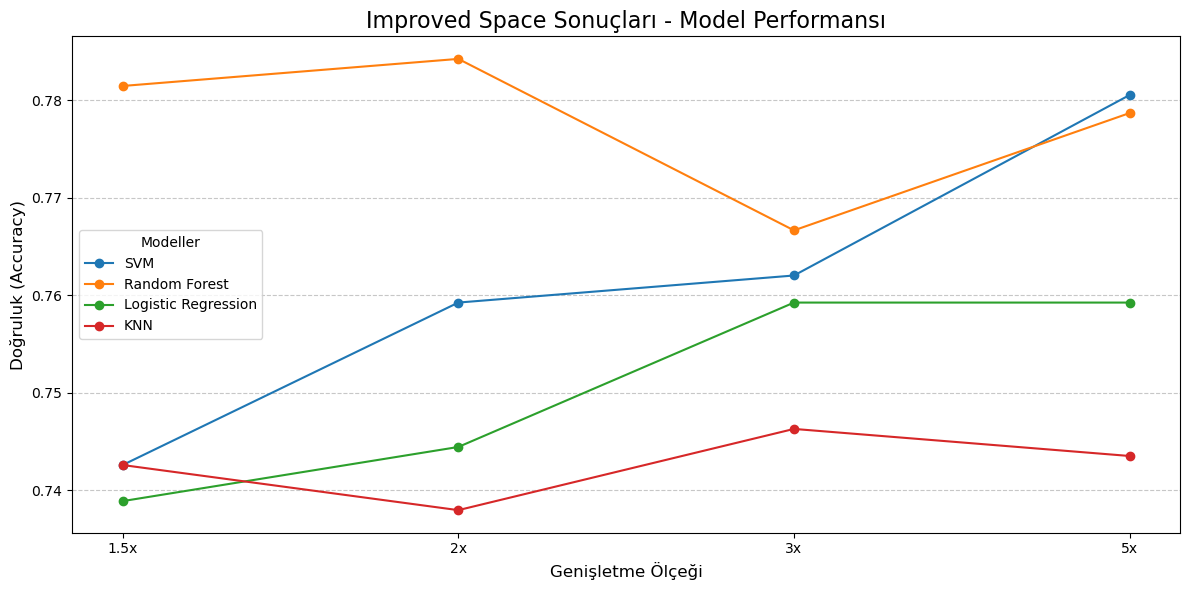

In [42]:
import matplotlib.pyplot as plt

# Create the plot dynamically
def plot_results(results):
    # Define scales for the plot
    scales = list(next(iter(results.values())).keys())  # Get scale keys of the first model
    
    # Plot
    plt.figure(figsize=(12, 6))
    
    for model_name, model_results in results.items():
        accuracies = [model_results[scale] for scale in scales]  # Accuracy by scale
        plt.plot(scales, accuracies, marker='o', label=model_name)  # accuracy curve per model
    
    # Adjust plot
    plt.title("Improved space results - Model Performansı", fontsize=16)
    plt.xlabel("Genişletme Ölçeği", fontsize=12)
    plt.ylabel("Doğruluk (Accuracy)", fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title="Modeller", fontsize=10)
    plt.tight_layout()
    
    # Show plot
    plt.show()

# Print results and plot
print("\nImproved space results:")
for model_name, model_results in results.items():
    print(f"\n{model_name} results:")
    for scale, acc in model_results.items():
        print(f"{scale}: Accuracy = {acc:.4f}")

# Draw the dynamic plot
plot_results(results)



Improved space results - Tweets:

SVM results:
1.5x: Accuracy = 0.8317
2x: Accuracy = 0.8292
3x: Accuracy = 0.8100
5x: Accuracy = 0.7992

Random Forest results:
1.5x: Accuracy = 0.8158
2x: Accuracy = 0.8208
3x: Accuracy = 0.8225
5x: Accuracy = 0.8183

Logistic Regression results:
1.5x: Accuracy = 0.8517
2x: Accuracy = 0.8500
3x: Accuracy = 0.8333
5x: Accuracy = 0.8267

KNN results:
1.5x: Accuracy = 0.7917
2x: Accuracy = 0.7942
3x: Accuracy = 0.7958
5x: Accuracy = 0.8042


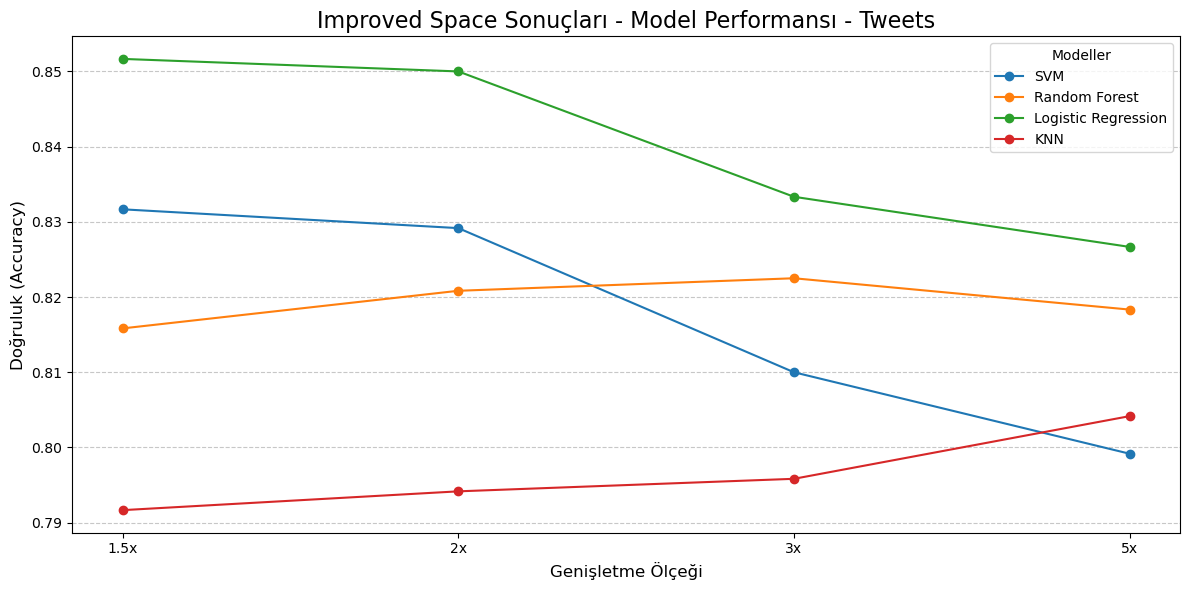

In [54]:
import matplotlib.pyplot as plt

# Create the plot dynamically
def plot_results(results):
    # Define scales for the plot
    scales = list(next(iter(results.values())).keys())  # Get scale keys of the first model
    
    # Plot
    plt.figure(figsize=(12, 6))
    
    for model_name, model_results in results.items():
        accuracies = [model_results[scale] for scale in scales]  # Accuracy by scale
        plt.plot(scales, accuracies, marker='o', label=model_name)  # accuracy curve per model
    
    # Adjust plot
    plt.title("Improved space results - Model Performansı - Tweets", fontsize=16)
    plt.xlabel("Genişletme Ölçeği", fontsize=12)
    plt.ylabel("Doğruluk (Accuracy)", fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title="Modeller", fontsize=10)
    plt.tight_layout()
    
    # Show plot
    plt.show()

# Print results and plot
print("\nImproved space results - Tweets:")
for model_name, model_results in results_2.items():
    print(f"\n{model_name} results:")
    for scale, acc in model_results.items():
        print(f"{scale}: Accuracy = {acc:.4f}")

# Draw the dynamic plot
plot_results(results_2)


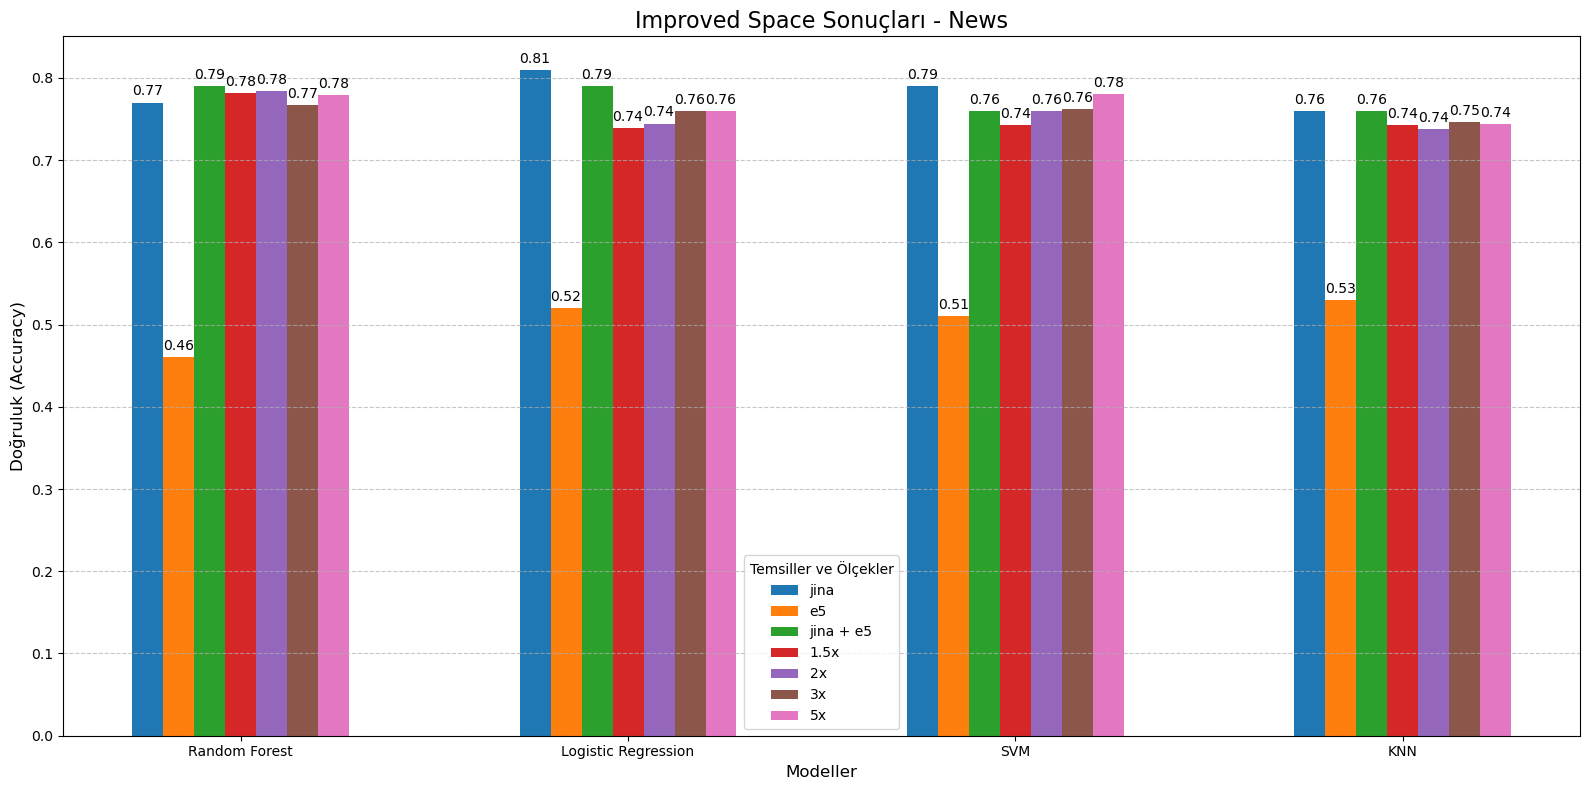

In [70]:
import matplotlib.pyplot as plt
import numpy as np

# Define results
results = {
    'SVM': {
        'jina': 0.79, 'e5': 0.51, 'jina + e5': 0.76,
        '1.5x': 0.7426, '2x': 0.7593, '3x': 0.7620, '5x': 0.7806
    },
    'Random Forest': {
        'jina': 0.77, 'e5': 0.46, 'jina + e5': 0.79,
        '1.5x': 0.7815, '2x': 0.7843, '3x': 0.7667, '5x': 0.7787
    },
    'Logistic Regression': {
        'jina': 0.81, 'e5': 0.52, 'jina + e5': 0.79,
        '1.5x': 0.7389, '2x': 0.7444, '3x': 0.7593, '5x': 0.7593
    },
    'KNN': {
        'jina': 0.76, 'e5': 0.53, 'jina + e5': 0.76,
        '1.5x': 0.7426, '2x': 0.7380, '3x': 0.7463, '5x': 0.7435
    },
}


# Models on the x axis
categories = ['Random Forest', 'Logistic Regression', 'SVM', 'KNN']
x = np.arange(len(categories))  # Positions for the x axis
bar_width = 0.08  # Bar width

# Create plot
plt.figure(figsize=(16, 8))

# Draw bars for Jina, E5 and other scales
scales = ['jina', 'e5', 'jina + e5', '1.5x', '2x', '3x', '5x']
for i, scale in enumerate(scales):
    accuracies = [results[model][scale] for model in categories]  # Accuracy of each model for the selected scale
    bars = plt.bar(x + i * bar_width, accuracies, bar_width, label=scale)

    # Write values on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height + 0.005, f"{height:.2f}",
                 ha='center', va='bottom', fontsize=10)

# Adjust plot
plt.title("Improved space results - News", fontsize=16)
plt.xlabel("Modeller", fontsize=12)
plt.ylabel("Doğruluk (Accuracy)", fontsize=12)
plt.xticks(x + bar_width * (len(scales) - 1) / 2, categories, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Temsiller ve Ölçekler", fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show plot
plt.show()


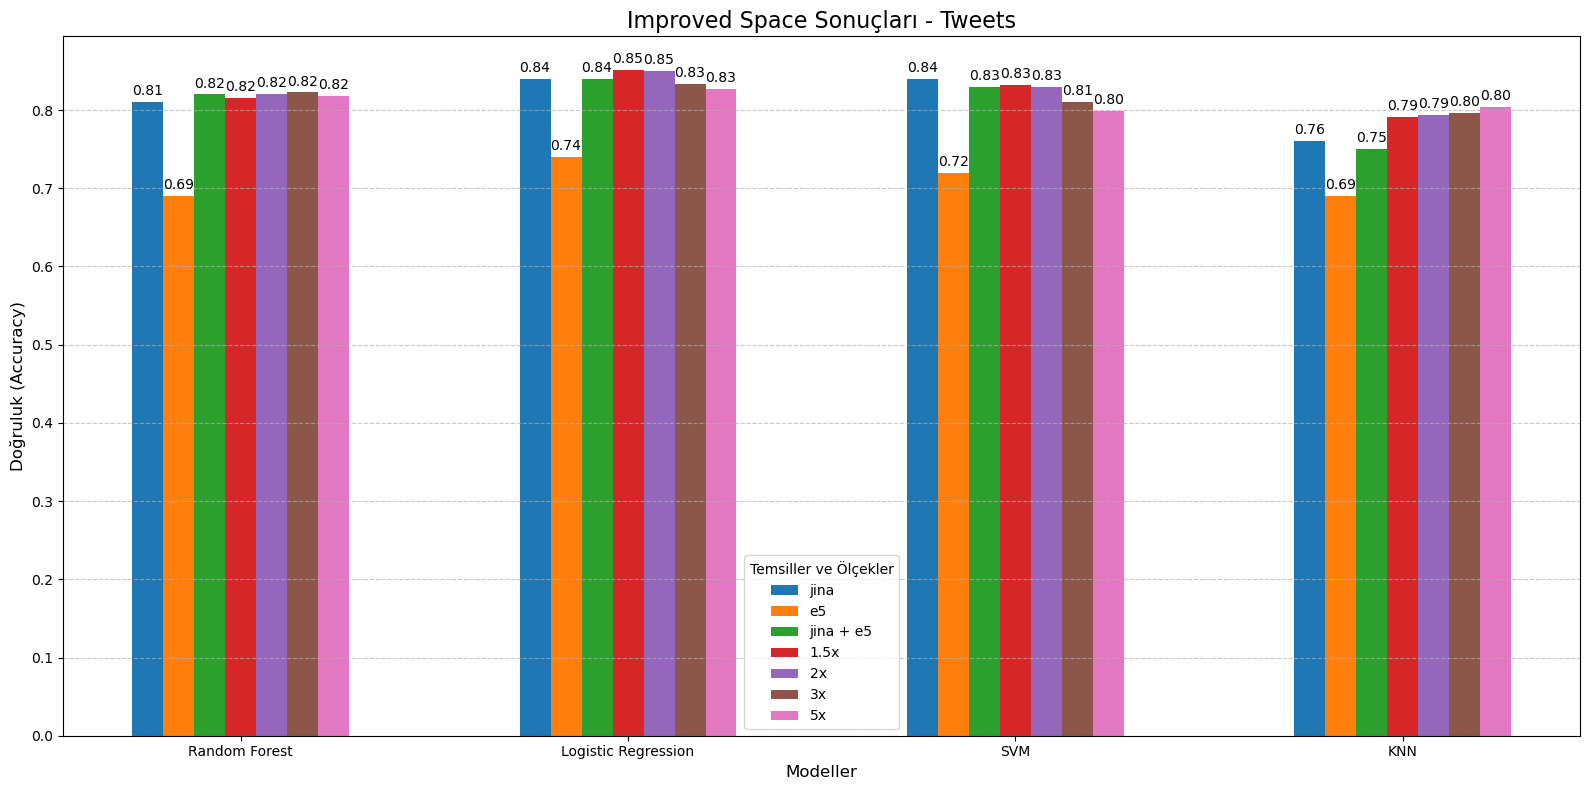

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# Define results
results = {
    'SVM': {'jina': 0.84, 'e5': 0.72, 'jina + e5': 0.83, '1.5x': 0.8317, '2x': 0.8292, '3x': 0.8100, '5x': 0.7992},
    'Random Forest': {'jina': 0.81, 'e5': 0.69, 'jina + e5': 0.82, '1.5x': 0.8158, '2x': 0.8208, '3x': 0.8225, '5x': 0.8183},
    'Logistic Regression': {'jina': 0.84, 'e5': 0.74, 'jina + e5': 0.84, '1.5x': 0.8517, '2x': 0.8500, '3x': 0.8333, '5x': 0.8267},
    'KNN': {'jina': 0.76, 'e5': 0.69, 'jina + e5': 0.75, '1.5x': 0.7917, '2x': 0.7942, '3x': 0.7958, '5x': 0.8042},
}

# Models on the x axis
categories = ['Random Forest', 'Logistic Regression', 'SVM', 'KNN']
x = np.arange(len(categories))  # Positions for the x axis
bar_width = 0.08  # Bar width

# Create plot
plt.figure(figsize=(16, 8))

# Draw bars for Jina, E5 and other scales
scales = ['jina', 'e5', 'jina + e5', '1.5x', '2x', '3x', '5x']
for i, scale in enumerate(scales):
    accuracies = [results[model][scale] for model in categories]  # Accuracy of each model for the selected scale
    bars = plt.bar(x + i * bar_width, accuracies, bar_width, label=scale)

    # Write values on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height + 0.005, f"{height:.2f}",
                 ha='center', va='bottom', fontsize=10)

# Adjust plot
plt.title("Improved space results - Tweets", fontsize=16)
plt.xlabel("Modeller", fontsize=12)
plt.ylabel("Doğruluk (Accuracy)", fontsize=12)
plt.xticks(x + bar_width * (len(scales) - 1) / 2, categories, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Temsiller ve Ölçekler", fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show plot
plt.show()
